In [29]:
import pandas as pd
import numpy as np

WT = "/mnt/sunxh/Datasets_RNA/human_call/HEK293T_RNA004/feature/predict.hek293t.DRACH.tsv"

df = pd.read_csv(
    WT,
    sep="\t",
    header=None,
    names=["transcript_id", "pos", "motif", "read_id", "pred_label", "prob"]
)

df["pos"]  = df["pos"].astype(int)
df["prob"] = df["prob"].astype(float)

HIGH_TH      = 0.95
COV_TH_SITE  = 10
MOD_FRAC_TH  = 0.5

site_df = (
    df.groupby(["transcript_id", "pos", "motif"], as_index=False)
      .agg(
          n_reads=("prob", "size"),
          n_high =("prob", lambda x: (x > HIGH_TH).sum())
      )
)

site_df["high_frac"] = site_df["n_high"] / site_df["n_reads"]

site_df = site_df[site_df["n_reads"] >= COV_TH_SITE].copy()

site_df["is_mod_site"] = site_df["high_frac"] >= MOD_FRAC_TH

print("位点总数:", len(site_df))
print(site_df.head())

motif_stats = (
    site_df.groupby("motif", as_index=True)
           .agg(
               n_sites    =("is_mod_site", "size"),
               n_mod_sites=("is_mod_site", "sum"),
           )
)

motif_stats["mod_site_fraction"] = (
    motif_stats["n_mod_sites"] / motif_stats["n_sites"]
)

print("motif-level 统计：")
print(motif_stats.head())

D = ["A", "G", "T"]
R = ["A", "G"]
H = ["A", "C", "T"]
drach_list = sorted([d + r + "A" + "C" + h for d in D for r in R for h in H])

motif_stats = motif_stats.reindex(drach_list)

out_csv = "/mnt/sunxh/sunxh/wattmamba/new_result/supfig12_hekDRACH18motif_sitelevel_fraction.csv"
motif_stats.to_csv(out_csv)
print("motif-level 结果已保存至:", out_csv)

位点总数: 333483
        transcript_id  pos  motif  n_reads  n_high  high_frac  is_mod_site
0   ENST00000001146.6  493  TGACC       16       4       0.25        False
2   ENST00000001146.6  705  GGACA       12       0       0.00        False
4   ENST00000001146.6  770  TGACC       12       0       0.00        False
8   ENST00000001146.6  824  GGACC       12       0       0.00        False
10  ENST00000001146.6  863  GGACA       12       0       0.00        False
motif-level 统计：
       n_sites  n_mod_sites  mod_site_fraction
motif                                         
AAACA    27344          111           0.004059
AAACC    16764          104           0.006204
AAACT    21941           44           0.002005
AGACA    21724          261           0.012014
AGACC    19394          151           0.007786
motif-level 结果已保存至: /mnt/sunxh/sunxh/wattmamba/new_result/supfig12_hekDRACH18motif_sitelevel_fraction.csv


In [30]:
D = ["A", "G", "T"]
R = ["A", "G"]
H = ["A", "C", "T"]

drach_list = []
for d in D:
    for r in R:
        for h in H:
            drach_list.append(d + r + "A" + "C" + h)

drach_list = sorted(drach_list)
print(len(drach_list), drach_list)


18 ['AAACA', 'AAACC', 'AAACT', 'AGACA', 'AGACC', 'AGACT', 'GAACA', 'GAACC', 'GAACT', 'GGACA', 'GGACC', 'GGACT', 'TAACA', 'TAACC', 'TAACT', 'TGACA', 'TGACC', 'TGACT']


In [31]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu
matplotlib.rcParams["font.family"] = "Arial"
drach_site = site_df[site_df["motif"].isin(drach_list)].copy()

print("各 DRACH motif 的位点数：")
print(
    drach_site.groupby("motif")["high_frac"]  
             .size()
             .sort_index()
)

motif_order = sorted(drach_list)

data = [
    drach_site[drach_site["motif"] == m]["high_frac"].values
    for m in motif_order
]
rows = []
for m, arr in zip(motif_order, data):
    for v in arr:
        rows.append({"motif": m, "high_frac": float(v)})
out_df = pd.DataFrame(rows)
out_df.to_csv(
    "/mnt/sunxh/sunxh/wattmamba/new_result/supfig12_hekDRACH18motif.csv",
    index=False
)
groups = [arr for arr in data if len(arr) > 0]
H, p_kw = kruskal(*groups)

motif_interest = "GGACT"
x = drach_site[drach_site["motif"] == motif_interest]["high_frac"].values
y = drach_site[drach_site["motif"] != motif_interest]["high_frac"].values
U, p_u = mannwhitneyu(x, y, alternative="two-sided")

print(f"Kruskal–Wallis: H={H:.3f}, p={p_kw:.3e}")
print(f"{motif_interest} vs other DRACH: U={U:.3g}, p={p_u:.3e}")



各 DRACH motif 的位点数：
motif
AAACA    27344
AAACC    16764
AAACT    21941
AGACA    21724
AGACC    19394
AGACT    16492
GAACA    22265
GAACC    15063
GAACT    16782
GGACA    23593
GGACC    22307
GGACT    17637
TAACA    12334
TAACC     6973
TAACT    10315
TGACA    22905
TGACC    20346
TGACT    19304
Name: high_frac, dtype: int64
Kruskal–Wallis: H=10576.230, p=0.000e+00
GGACT vs other DRACH: U=3.29e+09, p=0.000e+00


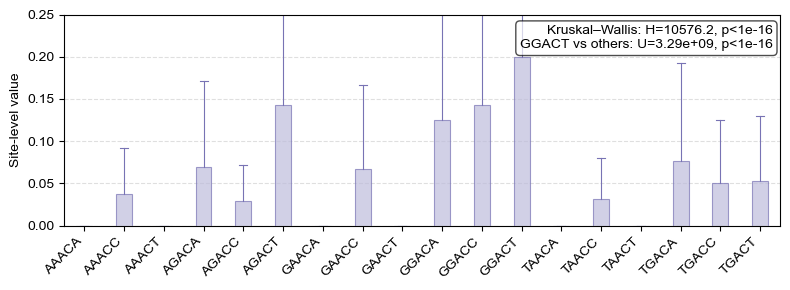

In [33]:
fig, ax = plt.subplots(figsize=(8, 3))
values_col = "high_frac"

positions = np.arange(1, len(motif_order) + 1)

main_color = (190/255, 188/255, 220/255)
edge_color = (120/255, 115/255, 180/255)

bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.4,         
    patch_artist=True,
    showfliers=False,     #  False
)

for box in bp["boxes"]:
    box.set(facecolor=main_color, alpha=0.7,
            edgecolor=edge_color, linewidth=0.8)
for whisker in bp["whiskers"]:
    whisker.set(color=edge_color, linewidth=0.8)
for cap in bp["caps"]:
    cap.set(color=edge_color, linewidth=0.8)
for median in bp["medians"]:
    median.set(color="white", linewidth=1.0)

ax.set_xticks(positions)
ax.set_xticklabels(motif_order, rotation=45, ha="right")

if values_col == "high_frac":
    ax.set_ylabel("Site-level value")
else:
    ax.set_ylabel("Site-level value")

ax.set_ylim(0, 0.25)
ax.set_yticks([0.0, 0.05, 0.10, 0.15, 0.20, 0.25])
ax.grid(axis="y", linestyle="--", alpha=0.4)

text = (
    f"Kruskal–Wallis: H={H:.1f}, p<1e-16\n"
    f"{motif_interest} vs others: U={U:.2e}, p<1e-16"
)
ax.text(
    0.99, 0.95, text,
    transform=ax.transAxes,
    va="top", ha="right",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
    zorder=5,
)

plt.tight_layout()
plt.savefig(
    "/mnt/sunxh/sunxh/wattmamba/new_result/supfig12_hekDRACH18motif_box_only.pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()


In [34]:
import pandas as pd
import numpy as np
WT = "/mnt/sunxh/Datasets_RNA/human_call/HEK293T_RNA004/feature/predict.hek293t.DRACH.tsv"
df = pd.read_csv(
    WT,
    sep="\t",
    header=None,
    names=["transcript_id", "pos", "motif", "read_id", "pred_label", "prob"]
)
df["pos"]  = df["pos"].astype(int)
df["prob"] = df["prob"].astype(float)
df["is_high_read"] = df["prob"] > 0.99
site_df = (
    df.groupby(["transcript_id", "pos", "motif"], as_index=False)
      .agg(
          n_high  = ("is_high_read", "sum"),   
          n_total = ("prob", "size"),          
      )
)

site_df["high_ratio"] = site_df["n_high"] / site_df["n_total"]

COV_TH   = 10
RATE_TH  = 0.3

site_df["is_high_site"] = (site_df["n_total"] >= COV_TH) & \
                          (site_df["high_ratio"] >= RATE_TH)

hc_sites = site_df[site_df["is_high_site"]].copy()
print("高置信位点数:", len(hc_sites))

motif_stats = (
    site_df[site_df["n_total"] >= COV_TH] 
    .groupby("motif")
    .agg(
        n_sites = ("high_ratio", "size"),     
        n_hc    = ("is_high_site", "sum"),     
    )
)
motif_stats["diff_mod"] = motif_stats["n_hc"] / motif_stats["n_sites"]
diff_mod_dict = motif_stats["diff_mod"].to_dict()
print("前几个 motif 的 diff_mod：")
print(motif_stats.sort_values("diff_mod", ascending=False).head())

高置信位点数: 1612
前几个 motif 的 diff_mod：
       n_sites  n_hc  diff_mod
motif                         
GGACT    17637   201  0.011396
GGACC    22307   185  0.008293
AGACT    16492   123  0.007458
GGACA    23593   166  0.007036
TGACA    22905   135  0.005894


In [35]:
import pandas as pd
import numpy as np

gtf_path = "/mnt/sunxh/Datasets_RNA/human_call/HEK293T_RNA004/Homo_sapiens.GRCh38.91.gtf"

site_df["tx_base"] = site_df["transcript_id"].astype(str).str.split(".", n=1).str[0]
target_tx_base = set(site_df["tx_base"].unique())
print("预测文件中 transcript 基础ID 个数:", len(target_tx_base))

def parse_gtf_attrs(attr_str):

    d = {}
    for field in attr_str.strip().split(";"):
        field = field.strip()
        if not field:
            continue
        if " " not in field:
            continue
        key, value = field.split(" ", 1)
        value = value.strip().replace('"', '')
        d[key] = value
    return d

tx_info = {}

with open(gtf_path, "r") as f:
    for line in f:
        if line.startswith("#"):
            continue
        fields = line.rstrip("\n").split("\t")
        if len(fields) < 9:
            continue

        chrom, source, feature, start, end, score, strand, frame, attrs = fields
        start = int(start)
        end   = int(end)
        length = end - start + 1

        d = parse_gtf_attrs(attrs)
        tid = d.get("transcript_id", None)
        if tid is None:
            continue

        tx_base = tid.split(".")[0]

        if tx_base not in target_tx_base:
            continue

        info = tx_info.setdefault(tx_base, {
            "gene_id":   d.get("gene_id"),
            "gene_name": d.get("gene_name"),
            "strand":    strand,
            "len_exon":  0,
            "len_cds":   0,
            "len_5utr":  0,
            "len_3utr":  0,
        })

        if feature == "exon":
            info["len_exon"] += length
        elif feature == "CDS":
            info["len_cds"] += length
        elif feature in ("five_prime_utr", "5UTR"):
            info["len_5utr"] += length
        elif feature in ("three_prime_utr", "3UTR"):
            info["len_3utr"] += length

if not tx_info:
    raise RuntimeError(
        "在 GTF 中没有找到任何与预测文件 transcript 匹配的记录。\n"
        "请检查：\n"
        "1) 预测文件中的 transcript_id 是否与 GTF 中一致（去掉 .版本号后）。\n"
        "2) gtf_path 路径是否正确。"
    )

tx_region_df = (
    pd.DataFrame.from_dict(tx_info, orient="index")
      .reset_index()
      .rename(columns={"index": "tx_base"})
)

print("tx_region_df 列：", tx_region_df.columns.tolist())
print("tx_region_df 行数:", len(tx_region_df))

tx_region_df["len_tx"] = tx_region_df["len_exon"]
mask_missing_exon = tx_region_df["len_tx"] == 0
tx_region_df.loc[mask_missing_exon, "len_tx"] = (
    tx_region_df.loc[mask_missing_exon, ["len_5utr", "len_cds", "len_3utr"]]
    .sum(axis=1)
)



hc_sites = site_df[site_df["is_high_site"]].copy()
hc_sites["tx_base"] = hc_sites["transcript_id"].astype(str).str.split(".", n=1).str[0]

hc_annot = hc_sites.merge(tx_region_df, on="tx_base", how="left")

print("合并后高置信位点数:", len(hc_annot))
print(hc_annot.head())


预测文件中 transcript 基础ID 个数: 5827
tx_region_df 列： ['tx_base', 'gene_id', 'gene_name', 'strand', 'len_exon', 'len_cds', 'len_5utr', 'len_3utr']
tx_region_df 行数: 5662
合并后高置信位点数: 1612
        transcript_id   pos  motif  n_high  n_total  high_ratio  is_high_site  \
0  ENST00000002501.10   574  GGACA       4       12    0.333333          True   
1  ENST00000002501.10  1875  AAACC       4       12    0.333333          True   
2   ENST00000064778.8  1800  TGACC       4       12    0.333333          True   
3   ENST00000064778.8  2556  AGACA       4       12    0.333333          True   
4   ENST00000064778.8  3152  GGACC       4       12    0.333333          True   

           tx_base          gene_id gene_name strand  len_exon  len_cds  \
0  ENST00000002501  ENSG00000003249    DBNDD1      -    2079.0    474.0   
1  ENST00000002501  ENSG00000003249    DBNDD1      -    2079.0    474.0   
2  ENST00000064778  ENSG00000054965   FAM168A      -    7296.0    732.0   
3  ENST00000064778  ENSG00000054965

In [36]:
hc_annot = hc_annot.copy()

hc_annot = hc_annot[(hc_annot["len_tx"] > 0) & (hc_annot["len_cds"] > 0)].copy()

def classify_region(row):
    pos  = row["pos"]
    L5   = row["len_5utr"]
    Lcds = row["len_cds"]
    L3   = row["len_3utr"]

    if pd.isna(L5):   L5 = 0
    if pd.isna(Lcds): Lcds = 0
    if pd.isna(L3):   L3 = 0

    if pos <= L5:
        return "5UTR"
    elif pos <= L5 + Lcds:
        return "CDS"
    elif pos <= L5 + Lcds + L3:
        return "3UTR"
    else:
        return "other"

hc_annot["region"] = hc_annot.apply(classify_region, axis=1)

hc_annot["rel_pos_cds"] = np.where(
    hc_annot["region"] == "CDS",
    (hc_annot["pos"] - hc_annot["len_5utr"]) / hc_annot["len_cds"],
    np.nan
)

hc_annot["dist_polyA"] = hc_annot["len_tx"] - hc_annot["pos"] + 1

hc_annot[["transcript_id", "pos", "motif", "region", "rel_pos_cds", "dist_polyA"]].head()
hc_annot[
    ["transcript_id", "pos", "motif", "region", "rel_pos_cds", "dist_polyA"]
].to_csv(
    "/mnt/sunxh/sunxh/wattmamba/new_result/supfig12_hek293DRACH_site_region_pos.tsv",
    sep="\t",
    index=False
)

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Arial"

hc_meta = hc_annot.copy()

L5_seg  = 1.0 / 3.0
LCDS_seg = 1.0
L3_seg  = 1.0 / 3.0

def compute_meta_pos_131(row):
    pos  = row["pos"]
    L5   = row["len_5utr"]
    Lcds = row["len_cds"]
    L3   = row["len_3utr"]
    region = row["region"]

    if pd.isna(L5):   L5 = 0
    if pd.isna(Lcds): Lcds = 0
    if pd.isna(L3):   L3 = 0

    if region == "5UTR" and L5 > 0:
        return -L5_seg + (pos / L5) * L5_seg

    elif region == "CDS" and Lcds > 0:
        return (pos - L5) / Lcds * LCDS_seg   # = (pos-L5)/Lcds

    elif region == "3UTR" and L3 > 0:
        return LCDS_seg + (pos - L5 - Lcds) / L3 * L3_seg

    else:
        return np.nan


hc_meta["meta_pos"] = hc_meta.apply(compute_meta_pos_131, axis=1)
hc_meta_plot = hc_meta.dropna(subset=["meta_pos"]).copy()
print("用于 meta-density 的位点数:", len(hc_meta_plot))

print("可用于 meta-density 的高置信位点数:", len(hc_meta))

用于 meta-density 的位点数: 1565
可用于 meta-density 的高置信位点数: 1569


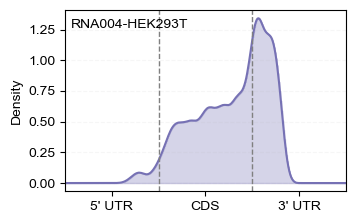

In [38]:

bins = np.linspace(-1.0, 2.0, 301)
hist, edges = np.histogram(
    hc_meta_plot["meta_pos"].values,
    bins=bins,
    density=True
)
centers = (edges[:-1] + edges[1:]) / 2
sigma = 5.5
half_window = int(3*sigma)
x = np.arange(-half_window, half_window + 1)
kernel = np.exp(-(x**2) / (2 * sigma**2))
kernel = kernel / kernel.sum()
smooth_hist = np.convolve(hist, kernel, mode="same")
main_color = (118/255, 113/255, 180/255)
fig, ax = plt.subplots(figsize=(3.66, 2.33))
ax.fill_between(centers, smooth_hist, step="mid", alpha=0.3, color=main_color)
ax.plot(centers, smooth_hist, "-", color=main_color, linewidth=1.5)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(1, color="gray", linestyle="--", linewidth=1)

for v in [-1, 0, 1, 2]:
    ax.axvline(v, color="grey", linestyle=":", linewidth=0.1, alpha=0.7)

ax.set_xlim(-1.0, 2.0)

ax.set_xticks([-0.5, 0.5, 1.5])
ax.set_xticklabels(["5' UTR", "CDS", "3' UTR"])

ax.set_ylabel("Density")
ax.set_xlabel("")

ax.text(0.02, 0.95, "RNA004-HEK293T",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10)

ax.grid(axis="y", linestyle="--", alpha=0.1)

plt.tight_layout()
plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig12_DRACH_meta_5UTR_CDS_3UTR_density_smooth.pdf",
            dpi=1200, bbox_inches="tight")
plt.show()

3' 端 0–1000 nt 内高置信位点数: 491


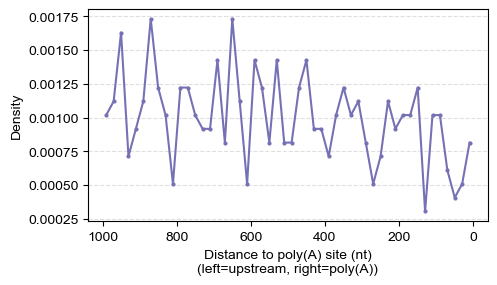

In [40]:
poly_window = 1000
poly_sites = hc_annot[(hc_annot["dist_polyA"] >= 0) &
                      (hc_annot["dist_polyA"] <= poly_window)].copy()

print("3' 端 0–1000 nt 内高置信位点数:", len(poly_sites))

bins = np.linspace(0, poly_window, 51)
hist, edges = np.histogram(poly_sites["dist_polyA"].values, bins=bins, density=True)
centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(5, 3))
plt.plot(centers, hist, "-o", markersize=2,
         color=(118/255, 113/255, 180/255))
plt.gca().invert_xaxis()
plt.xlabel("Distance to poly(A) site (nt)\n(left=upstream, right=poly(A))")
plt.ylabel("Density")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig12_DRACH_meta_polyA.pdf",
            dpi=1200, bbox_inches="tight")
plt.show()

In [41]:
import pandas as pd
import numpy as np
WT = "/mnt/sunxh/Datasets_RNA/human_call/HEK293T_RNA004/feature/predict.hek293t.DRACH.tsv"
df = pd.read_csv(
    WT,
    sep="\t",
    header=None,
    names=["transcript_id", "pos", "motif", "read_id", "pred_label", "prob"]
)
df["pos"]  = df["pos"].astype(int)
df["prob"] = df["prob"].astype(float)
df["is_high_read"] = df["prob"] > 0.92
site_df = (
    df.groupby(["transcript_id", "pos", "motif"], as_index=False)
      .agg(
          n_high  = ("is_high_read", "sum"),   
          n_total = ("prob", "size"),          
      )
)

site_df["high_ratio"] = site_df["n_high"] / site_df["n_total"]

COV_TH   = 10
RATE_TH  = 0.3

site_df["is_high_site"] = (site_df["n_total"] >= COV_TH) & \
                          (site_df["high_ratio"] >= RATE_TH)

hc_sites = site_df[site_df["is_high_site"]].copy()
print("高置信位点数:", len(hc_sites))

motif_stats = (
    site_df[site_df["n_total"] >= COV_TH] 
    .groupby("motif")
    .agg(
        n_sites = ("high_ratio", "size"),     
        n_hc    = ("is_high_site", "sum"),     
    )
)
motif_stats["diff_mod"] = motif_stats["n_hc"] / motif_stats["n_sites"]
diff_mod_dict = motif_stats["diff_mod"].to_dict()
print("前几个 motif 的 diff_mod：")
print(motif_stats.sort_values("diff_mod", ascending=False).head())
import pandas as pd
import numpy as np

gtf_path = "/mnt/sunxh/Datasets_RNA/human_call/HEK293T_RNA004/Homo_sapiens.GRCh38.91.gtf"

site_df["tx_base"] = (
    site_df["transcript_id"]
    .astype(str)
    .str.split(".", n=1)
    .str[0]
)
target_tx_base = set(site_df["tx_base"].unique())
print("预测文件中 transcript 基础ID 个数:", len(target_tx_base))

def parse_gtf_attrs(attr_str):

    d = {}
    for field in attr_str.strip().split(";"):
        field = field.strip()
        if not field:
            continue
        if " " not in field:
            continue
        key, value = field.split(" ", 1)
        value = value.strip().replace('"', '')
        d[key] = value
    return d

tx_info = {}

with open(gtf_path, "r") as f:
    for line in f:
        if line.startswith("#"):
            continue
        fields = line.rstrip("\n").split("\t")
        if len(fields) < 9:
            continue

        chrom, source, feature, start, end, score, strand, frame, attrs = fields
        start = int(start)
        end   = int(end)
        length = end - start + 1

        d = parse_gtf_attrs(attrs)
        tid = d.get("transcript_id", None)
        if tid is None:
            continue

        tx_base = tid.split(".")[0]

        if tx_base not in target_tx_base:
            continue

        info = tx_info.setdefault(tx_base, {
            "gene_id":   d.get("gene_id"),
            "gene_name": d.get("gene_name"),
            "strand":    strand,
            "len_exon":  0,
            "len_cds":   0,
            "len_5utr":  0,
            "len_3utr":  0,
        })

        if feature == "exon":
            info["len_exon"] += length
        elif feature == "CDS":
            info["len_cds"] += length
        elif feature in ("five_prime_utr", "5UTR"):
            info["len_5utr"] += length
        elif feature in ("three_prime_utr", "3UTR"):
            info["len_3utr"] += length

if not tx_info:
    raise RuntimeError(
        "在 GTF 中没有找到任何与预测文件 transcript 匹配的记录。\n"
        "请检查：\n"
        "1) 预测文件中的 transcript_id 是否与 GTF 中一致（去掉 .版本号后）。\n"
        "2) gtf_path 路径是否正确。"
    )

tx_region_df = (
    pd.DataFrame.from_dict(tx_info, orient="index")
      .reset_index()
      .rename(columns={"index": "tx_base"})
)

print("tx_region_df 列：", tx_region_df.columns.tolist())
print("tx_region_df 行数:", len(tx_region_df))

tx_region_df["len_tx"] = tx_region_df["len_exon"]
mask_missing_exon = tx_region_df["len_tx"] == 0
tx_region_df.loc[mask_missing_exon, "len_tx"] = (
    tx_region_df.loc[mask_missing_exon, ["len_5utr", "len_cds", "len_3utr"]]
    .sum(axis=1)
)



hc_sites = site_df[site_df["is_high_site"]].copy()
hc_sites["tx_base"] = hc_sites["transcript_id"].astype(str).str.split(".", n=1).str[0]

hc_annot = hc_sites.merge(tx_region_df, on="tx_base", how="left")

print("合并后高置信位点数:", len(hc_annot))
print(hc_annot.head())


高置信位点数: 47527
前几个 motif 的 diff_mod：
       n_sites  n_hc  diff_mod
motif                         
GGACT    17637  4627  0.262346
AGACT    16492  3473  0.210587
GGACC    22307  4566  0.204689
GGACA    23593  4383  0.185775
GAACC    15063  2389  0.158601
预测文件中 transcript 基础ID 个数: 5827
tx_region_df 列： ['tx_base', 'gene_id', 'gene_name', 'strand', 'len_exon', 'len_cds', 'len_5utr', 'len_3utr']
tx_region_df 行数: 5662
合并后高置信位点数: 47527
        transcript_id  pos  motif  n_high  n_total  high_ratio  is_high_site  \
0   ENST00000001146.6  824  GGACC       4       12    0.333333          True   
1  ENST00000002501.10  229  GGACA       8       16    0.500000          True   
2  ENST00000002501.10  230  GGACA       8       24    0.333333          True   
3  ENST00000002501.10  432  GAACC       4       12    0.333333          True   
4  ENST00000002501.10  574  GGACA       4       12    0.333333          True   

           tx_base          gene_id gene_name strand  len_exon  len_cds  \
0  ENST00000

In [42]:
import gseapy as gp
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "Arial"


fg_genes = (
    hc_annot["gene_name"]
    .dropna()
    .astype(str)
)
fg_genes = sorted(set([g for g in fg_genes.tolist() if g != ""]))
print("前景基因数:", len(fg_genes))

all_sites = site_df.copy()
all_sites["tx_base"] = (
    all_sites["transcript_id"]
    .astype(str)
    .str.split(".", n=1)
    .str[0]
)

all_sites = all_sites.merge(
    tx_region_df[["tx_base", "gene_name"]],
    on="tx_base",
    how="left"
)

bg_genes = (
    all_sites["gene_name"]
    .dropna()
    .astype(str)
)
bg_genes = sorted(set([g for g in bg_genes.tolist() if g != ""]))
print("背景基因数:", len(bg_genes))


enr_go = gp.enrichr(
    gene_list = fg_genes,
    gene_sets = ["GO_Biological_Process_2021"],
    organism  = "Human",
    outdir    = "/mnt/sunxh/Datasets_RNA/human_call/HEK293T_RNA004/enrich/DRACH_GO",
    cutoff    = 0.05,
)

go_all = enr_go.results
print("GO 结果列名:", go_all.columns.tolist())

go_res = (
    go_all
    .sort_values("Adjusted P-value")
    .head(20)
    .copy()
)

go_res = go_res.iloc[::-1]

go_res["minus_log10_FDR"] = -np.log10(go_res["Adjusted P-value"].astype(float))

# KEGG
enr_kegg = gp.enrichr(
    gene_list = fg_genes,
    gene_sets = ["KEGG_2021_Human"],
    organism  = "Human",
    outdir    = "/mnt/sunxh/Datasets_RNA/human_call/HEK293T_RNA004/enrich/DRACH_KEGG",
    cutoff    = 0.05,
)

kegg_all = enr_kegg.results
print("KEGG 结果列名:", kegg_all.columns.tolist())

kegg_res = (
    kegg_all
    .sort_values("Adjusted P-value")
    .head(20)
    .copy()
)
kegg_res = kegg_res.iloc[::-1]
kegg_res["minus_log10_FDR"] = -np.log10(kegg_res["Adjusted P-value"].astype(float))



前景基因数: 1530
背景基因数: 2435
GO 结果列名: ['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes']
KEGG 结果列名: ['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes']


/tmp/ipykernel_1290981/621889199.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


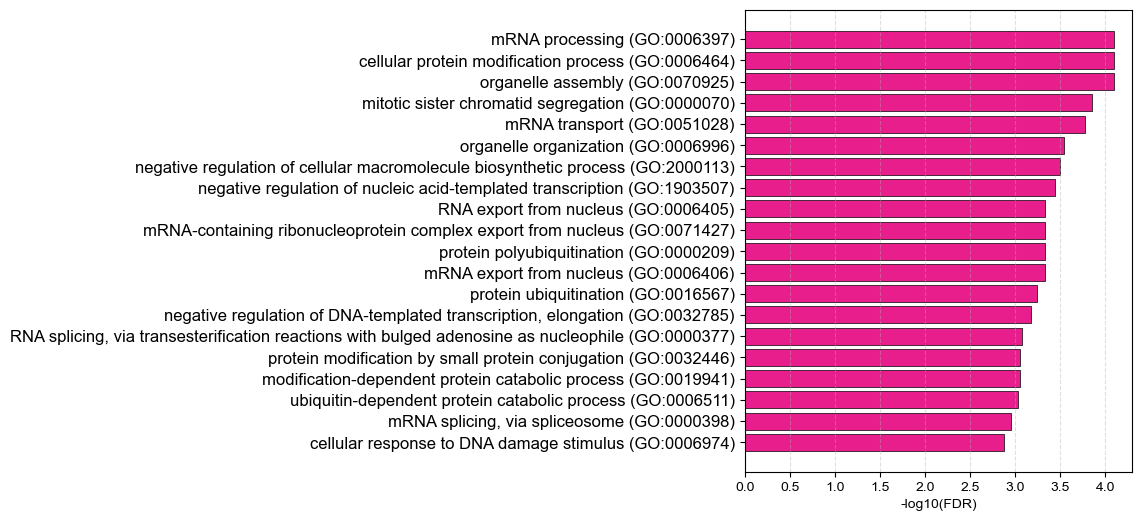

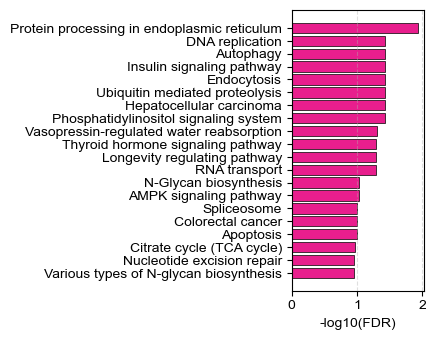

In [43]:

main_color = (232/255, 30/255, 141/255)
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Arial"]
fig, ax = plt.subplots(figsize=(5, 6))

ax.barh(
    go_res["Term"],
    go_res["minus_log10_FDR"],
    color=main_color,
    edgecolor="black",
    linewidth=0.5,
)

ax.set_xlabel("-log10(FDR)")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.savefig(
    "/mnt/sunxh/sunxh/wattmamba/new_result/supfig12_DRACH_GO_top20_barh.pdf",
    dpi=1200,
    bbox_inches="tight"
)
plt.show()


fig, ax = plt.subplots(figsize=(4.5, 3.5))

ax.barh(
    kegg_res["Term"],
    kegg_res["minus_log10_FDR"],
    color=main_color,
    edgecolor="black",
    linewidth=0.5,
)

ax.set_xlabel("-log10(FDR)")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(
    "/mnt/sunxh/sunxh/wattmamba/new_result/supfig12_DRACH_KEGG_top20_barh.pdf",
    dpi=1200,
    bbox_inches="tight"
)
plt.show()

